## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


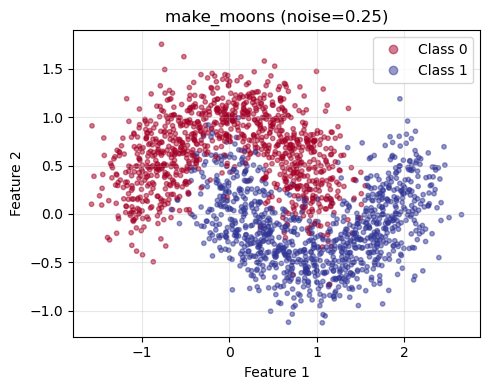

In [85]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [86]:
# X and Y 
X = X
y = y

# Train (order matters!!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= .3, random_state=42, stratify = y)

# Scale
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [87]:
# Create param grid for hyperparameter
param_grid = {
    "C" : [.001,.01,.1,1,10,100]
}

# Create grid search object for linear SVM
svc_linear_grid = GridSearchCV(
    SVC(random_state=42, kernel= "linear"),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit grid search to the training data
svc_linear_grid.fit(X_train_scale, y_train)

# Get best estimator and evaluate on test set
best_linear = svc_linear_grid.best_estimator_
test_acc_linear = accuracy_score(y_test, best_linear.predict(X_test_scale))

##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [88]:
# Create DataFrame to display results
results_linear = pd.DataFrame(svc_linear_grid.cv_results_)[['param_C', 'mean_test_score']]
results_linear

,param_C,mean_test_score
0,0.001,0.847143
1,0.01,0.853571
2,0.1,0.856429
3,1,0.860000
4,10,0.860000
5,100,0.860000


In [89]:
# Extract best C and gamma using best_params_ (more information: https://learn-scikit.oneoffcoder.com/hyperparam-tuning.html)
best_params_linear = svc_linear_grid.best_params_
best_C = best_params_linear.get('C')
print(f"Best C: {best_C}")
print(f"Test accuracy (linear kernel): {test_acc_linear:.4f}")

Best C: 1
Test accuracy (linear kernel): 0.8800


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

Cross validation selected a `C` value of 1. Given that the moons boundary is curved, I did not expect the linear kernel to achieve strong accuracy regardless of `C`. The accuracy stops improving at a `C` value of 1 (same accuracy for C = 10 and so on).

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [90]:
# Define param grid 
param_grid_rbf = {
 "C": [.01, 1, 10, 100], 
 "gamma": ["scale", .001, .01, 1, 10]
}

# Build kernel grid
rbf_grid = GridSearchCV(
    SVC(random_state=42, kernel= "rbf"),
    param_grid_rbf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on training data
rbf_grid.fit(X_train_scale, y_train)

best_rbf = rbf_grid.best_estimator_

test_acc_rbf = accuracy_score(y_test, best_rbf.predict(X_test_scale))

# Create df to display results
results_rbf = pd.DataFrame(rbf_grid.cv_results_)[['params', 'mean_test_score']]
results_rbf


,params,mean_test_score
0,"{'C': 0.01, 'gamma': 'scale'}",0.875714
1,"{'C': 0.01, 'gamma': 0.001}",0.847857
2,"{'C': 0.01, 'gamma': 0.01}",0.847857
3,"{'C': 0.01, 'gamma': 1}",0.904286
4,"{'C': 0.01, 'gamma': 10}",0.942857
5,"{'C': 1, 'gamma': 'scale'}",0.941429
6,"{'C': 1, 'gamma': 0.001}",0.846429
7,"{'C': 1, 'gamma': 0.01}",0.853571
8,"{'C': 1, 'gamma': 1}",0.947857
9,"{'C': 1, 'gamma': 10}",0.946429


In [115]:
# Extract best C and gamma using best_params_ (more information: https://learn-scikit.oneoffcoder.com/hyperparam-tuning.html)
best_params_rbf = rbf_grid.best_params_
best_C = best_params_rbf.get('C')
best_gamma = best_params_rbf.get('gamma')

print(f"Best C: {best_C}")
print(f"Best gamma: {best_gamma}")
print(f"Best RBF params: {rbf_grid.best_params_}")
print(f"Best RBF CV accuracy: {rbf_grid.best_score_:.4f}")
print(f"Test accuracy (RBF): {test_acc_rbf:.4f}")

Best C: 1
Best gamma: 1
Best RBF params: {'C': 1, 'gamma': 1}
Best RBF CV accuracy: 0.9479
Test accuracy (RBF): 0.9383


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The RBF kernel improves the test accuracy from 0.88 to 0.938 by about .057. `best_params_` shows that the best `C` value is 1 and the best `gamma` value is 1. Both values are moderate in the middle of the search grid; extreme values (ex. 10, 100) were not selected. This suggests a relatively smooth-fitted boundary.

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [93]:
# Create param grid
param_grid_poly = {
    "C" : [.1,1,10,100],
    "gamma" : ["scale", .001, .01, .1, 1],
    "degree" : [2,3,4],
    "coef0" : [0,1]
}

# Build kernel grid
poly_grid = GridSearchCV(
    SVC(random_state=42, kernel= "poly"),
    param_grid_poly,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on training data
poly_grid.fit(X_train_scale, y_train)

best_poly = poly_grid.best_estimator_
test_acc_poly = accuracy_score(y_test, best_poly.predict(X_test_scale))

# Create df to display results
results_poly = pd.DataFrame(poly_grid.cv_results_)[['params', 'mean_test_score']]
results_poly

,params,mean_test_score
0,"{'C': 0.1, 'coef0': 0, 'degree': 2, 'gamma': '...",0.485000
1,"{'C': 0.1, 'coef0': 0, 'degree': 2, 'gamma': 0...",0.493571
2,"{'C': 0.1, 'coef0': 0, 'degree': 2, 'gamma': 0...",0.493571
3,"{'C': 0.1, 'coef0': 0, 'degree': 2, 'gamma': 0.1}",0.493571
4,"{'C': 0.1, 'coef0': 0, 'degree': 2, 'gamma': 1}",0.481429
...,...,...
115,"{'C': 100, 'coef0': 1, 'degree': 4, 'gamma': '...",0.944286
116,"{'C': 100, 'coef0': 1, 'degree': 4, 'gamma': 0...",0.859286
117,"{'C': 100, 'coef0': 1, 'degree': 4, 'gamma': 0...",0.872857
118,"{'C': 100, 'coef0': 1, 'degree': 4, 'gamma': 0.1}",0.942857


In [112]:
# Extract best C and gamma using best_params_ (more information: https://learn-scikit.oneoffcoder.com/hyperparam-tuning.html)
best_params_poly = poly_grid.best_params_
best_degree = best_params_poly.get('degree')

print(f"Best degree: {best_degree}")
print(f"Best Poly params: {poly_grid.best_params_}")
print(f"Best Poly CV accuracy: {poly_grid.best_score_:.4f}")
print(f"Test accuracy (Poly): {test_acc_poly:.4f}")

Best degree: 3
Best Poly params: {'C': 1, 'coef0': 1, 'degree': 3, 'gamma': 1}
Best Poly CV accuracy: 0.9450
Test accuracy (Poly): 0.9400


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

`GridSearchCV` selected a degree of 3 for the polynomial with the best test accuracy being .94 (`test_acc_poly`). The polynomial fit only marginally improved the test accuracy compared to the RBF kernel (.00169 difference). This is a prime example of a higher degree not always improving the accuracy of a model's fit because the data's underlying boundary has a moderate curvature; once the model captures the shape, the higher polynomial degrees will add more complexity witout improving the fit. This increases variance and the chances of overfitting to the data. 

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [96]:
# Create combined param grid 
param_grid_all = [
{
    "kernel": ["linear"], 
    "C" : [0.1, .1, 1, 10, 100], 
}, 
{
    "kernel" : ["rbf"], 
    "gamma": ["scale", .001, .01, .1, 1, 10], 
    "C": [0.1, 1, 10, 100]
}, 
{
    "kernel": ["poly"], 
    "C": [0.1,1,10, 100], 
    "gamma": ["scale", .001, .01, .1,1], 
    "degree" : [2,3,4], 
    "coef0": [0,1]
}
]
# Combine kernels into grid search
grid_overall = GridSearchCV(
    SVC(random_state=42), 
    param_grid=param_grid_all, 
    cv = 5, 
    scoring = "accuracy", 
    n_jobs = -1
)

In [109]:
# Fit to trained data 
grid_overall.fit(X_train_scale, y_train)

best_overall = grid_overall.best_estimator_

test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_scale))

print(f"Best params: {grid_overall.best_params_}")
print(f"CV accuracy: {grid_overall.best_score_:.3f}")
print(f"Test accuracy: {test_acc_overall}")

Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV accuracy: 0.948
Test accuracy: 0.9383333333333334


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The kernel selected the RBF as the best overall kernel with a C = 1 and gamma = 1, where the CV and test accuracies reached .948 and .938, respectively. The polynomial kernel achieved essentially an extremely similar performance as the RBF kernel (.94 vs .938) because both can model the curved boundary. The overall search selected the RBF kernel because its CV accuracy (.948) was slightly higher than the CV accuracy of the polynomial kernel (.94, see Step 5). It is important to note that both the RBF and polynomial kernels performed essentially the same on the scaled test set. Both captured the nonlinear boundary well, whereas the linear kernel could not represent the curvature. 

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [110]:
# Create param grid for random forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Create grid search
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit to training data
grid_rf.fit(X_train_scale, y_train)
best_rf = grid_rf.best_estimator_
test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test_scale))


In [111]:
print(f"Best RF params: {grid_rf.best_params_}")
print(f"Best RF CV accuracy: {grid_rf.best_score_:.4f}")
print(f"Test accuracy (RF): {test_acc_rf:.4f}")

Best RF params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Best RF CV accuracy: 0.9464
Test accuracy (RF): 0.9383


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

The random forest achieved a .938 test accuracy, essentially matching the RBF kernel's test accuracy. Random forest also clealy outperforms the linear SVM. The RBF kernel also had a slightly higher CV accuracy compared to the random forest. This suggest that the data requires a nonlinear decision boundary but not one that is too complex.

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

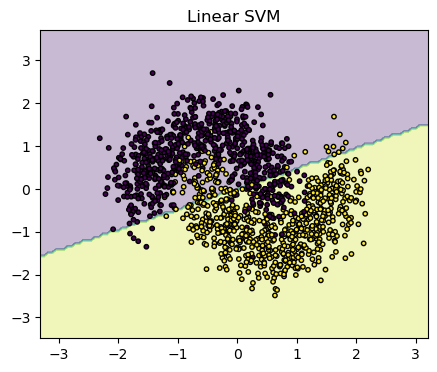

In [99]:
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(best_linear, X_train_scale, ax = ax, response_method="predict", alpha = .3)
ax.scatter(X_train_scale[:,0], X_train_scale[:,1], c = y_train, s = 10, edgecolors="k")
ax.set_title("Linear SVM")
plt.show()

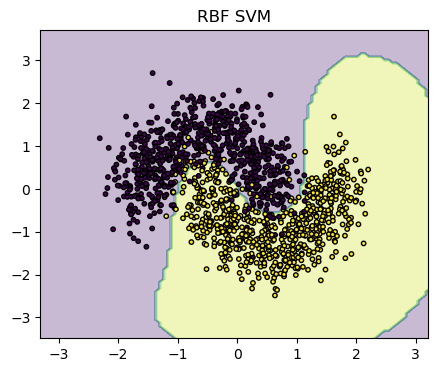

In [116]:
# RBF decision boundary
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(best_rbf, X_train_scale, ax = ax, response_method="predict", alpha = .3)
ax.scatter(X_train_scale[:,0], X_train_scale[:,1], c = y_train, s = 10, edgecolors="k")
ax.set_title("RBF SVM")
plt.show()

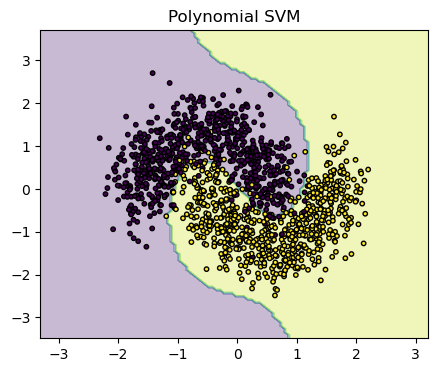

In [117]:
# Polynomial decision boundary
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(best_poly, X_train_scale, ax = ax, response_method="predict", alpha = .3)
ax.scatter(X_train_scale[:,0], X_train_scale[:,1], c = y_train, s = 10, edgecolors="k")
ax.set_title("Polynomial SVM")
plt.show()

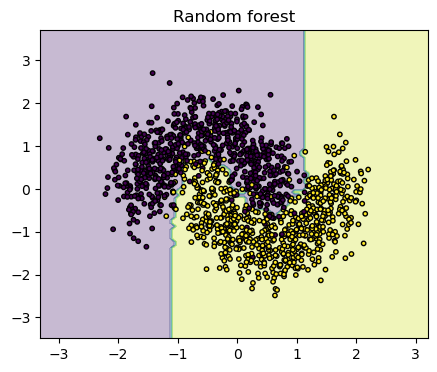

In [100]:
# Random forest decision boundary
fig, ax = plt.subplots(figsize = (5,4))
DecisionBoundaryDisplay.from_estimator(best_rf, X_train_scale, ax = ax, response_method="predict", alpha = .3)
ax.scatter(X_train_scale[:,0], X_train_scale[:,1], c = y_train, s = 10, edgecolors="k")
ax.set_title("Random forest")
plt.show()


> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

The linear kernel produces a single straight-line decision boundary that cuts diagonally across the feature space. It is clear that it does not and cannot follow the curved shape of the two moon-shaped classes, leading to many misclassified points near the overlapping regions. 

The decision boundaries of the RBF and polynomial kernels are clearly superior to the linear kernel decision boundary. The curved decision boundaries wrap nicely around the clusters. Their boundaries closely match the underlying structure of the data, allowing to separate the classes more effectively and achieve higher accuracies. Interestingly, the polynomial decision boundary curvature is slightly different from the RBF decision boundary, forming a "Ying-and-Yang" split between the two distinct classes. It does appear to slightly fit the distinct clusters better than the RBF.

The random forest also captures the non-linear shape of the moons but the boundary is notably different from the SVM boundaries. Rather than a smooth curve, there are rectangular, jagged, and smooth sections along the entire decision boundary. 

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

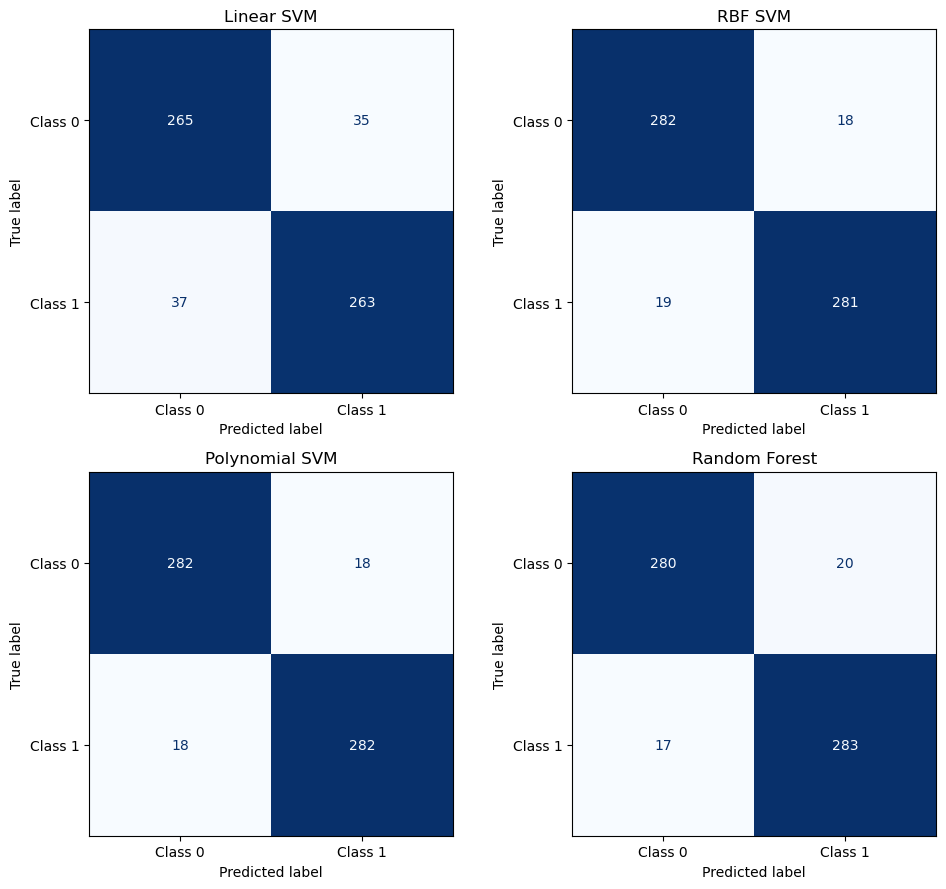

In [121]:
# Establish base plots, doing all in one pain is much easier
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

# Linear SVM
ConfusionMatrixDisplay.from_estimator(
    best_linear, X_test_scale, y_test,
    display_labels=['Class 0', 'Class 1'],
    cmap='Blues', ax=axes[0, 0], colorbar=False
)
axes[0, 0].set_title('Linear SVM')

# RBF SVM
ConfusionMatrixDisplay.from_estimator(
    best_rbf, X_test_scale, y_test,
    display_labels=['Class 0', 'Class 1'],
    cmap='Blues', ax=axes[0, 1], colorbar=False
)
axes[0, 1].set_title('RBF SVM')

# Polynomial SVM
ConfusionMatrixDisplay.from_estimator(
    best_poly, X_test_scale, y_test,
    display_labels=['Class 0', 'Class 1'],
    cmap='Blues', ax=axes[1, 0], colorbar=False
)
axes[1, 0].set_title('Polynomial SVM')

# Random Forest
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test_scale, y_test,
    display_labels=['Class 0', 'Class 1'],
    cmap='Blues', ax=axes[1, 1], colorbar=False
)
axes[1, 1].set_title('Random Forest')

plt.tight_layout()
plt.show()

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

All four models appear to show balanced error patterns, especially between false positives and false negatives occurring in almost equal numbers (linear: 35/37, RBF: 18/19, polynomial: 18/18, random forest: 20/17). This indicates that none of the models seems to be biased towards predicting one class over the other. The main difference is the total number of errors. For example, the linear kernel made 72 misclassifications. Essentially, the linear kernel's straight decision boundary cannot properly follow the curved structure of the two moons, leading to many misclassifications.

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


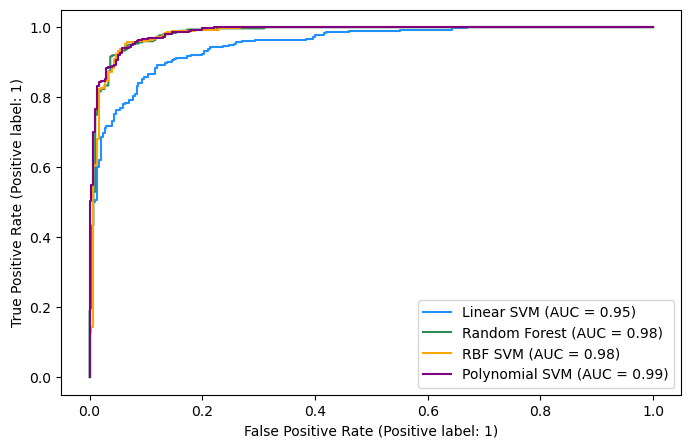

In [122]:
fig, ax = plt.subplots(figsize = (8,5))
RocCurveDisplay.from_estimator(best_linear, X_test_scale, y_test, name = "Linear SVM", ax = ax, color = "DodgerBlue")
RocCurveDisplay.from_estimator(best_rf, X_test_scale, y_test, name = "Random Forest", ax = ax, color = "seagreen")
RocCurveDisplay.from_estimator(best_rbf, X_test_scale, y_test, name = "RBF SVM", ax = ax, color = "orange") 
RocCurveDisplay.from_estimator(best_poly, X_test_scale, y_test, name = "Polynomial SVM", ax = ax, color = "purple")

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

I would choose the polynomial SVM based on the AUC being slightly higher and misclassification ratio being balanced (18:18), although the RBF SVM is essentially tied in performance. The nonlinear models all achieved identical accuracy and AUC scores, so the deciding factor likely comes down to how closely their decision boundaries match the data. The RBF kernel produces a smooth nonlinear boundary that closely follows this structure; however, the polynomial kernel visually appears to cover more area above the clusters to create "more space" to capture yellow or purple observations in their appropriate classes. The random forest achieved a similar accuracy, but its boundary is more jagged; this appears as a less natural representation of the underlying geometry of the data.

One could also argue to choose the RBF kernel over the polynomial kernel on the grounds of requiring fewer hyperparameters. Generally, parsimony is desirable. The linear SVM is clearly the weakest option because its straight-line boundary cannot capture the curved separation between the two classes.

>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**